In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def euler_matrix(k, h):
    """Return the Euler update matrix A for step size h."""
    return np.array([[1, h],
                     [-k*h, 1]])

def simulate_euler(k, h, y0=1.0, v0=0.0, t_end=10):
    """Simulate the Euler method for the oscillator."""
    t = np.arange(0, t_end + h, h)
    y = np.zeros_like(t)
    v = np.zeros_like(t)

    y[0], v[0] = y0, v0
    A = euler_matrix(k, h)

    for i in range(1, len(t)):
        state = A @ np.array([y[i-1], v[i-1]])
        y[i], v[i] = state[0], state[1]

    return t, y, v

## Loop Over Step Sizes and Analyze Stability


Step size h = 0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)


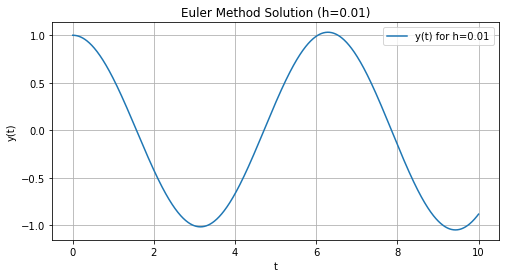


Step size h = 0.02
Eigenvalues: [1.+0.02j 1.-0.02j]
Magnitudes: [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)


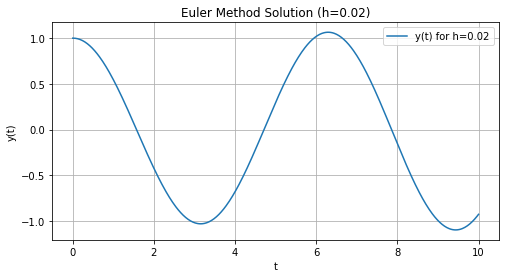


Step size h = 0.03
Eigenvalues: [1.+0.03j 1.-0.03j]
Magnitudes: [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)


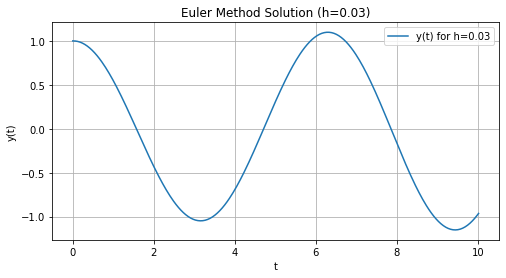


Step size h = 0.05
Eigenvalues: [1.+0.05j 1.-0.05j]
Magnitudes: [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)


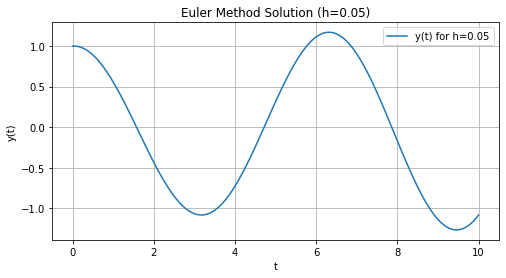


Step size h = 0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)


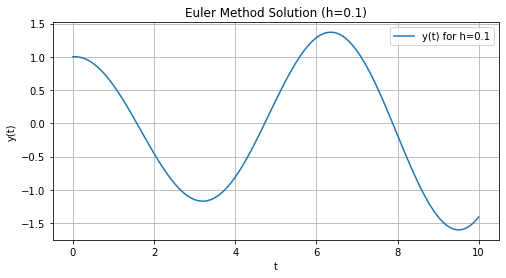


Step size h = 0.2
Eigenvalues: [1.+0.2j 1.-0.2j]
Magnitudes: [1.0198039 1.0198039]
Solution may not be Entirely Stable ;)


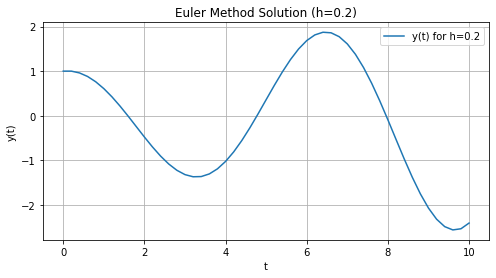


Step size h = 0.3
Eigenvalues: [1.+0.3j 1.-0.3j]
Magnitudes: [1.04403065 1.04403065]
Solution may not be Entirely Stable ;)


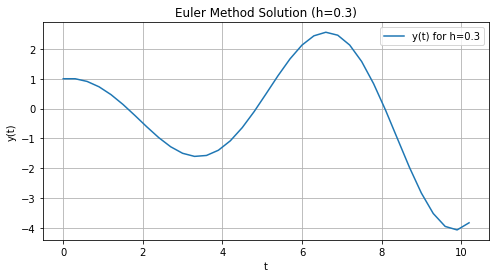


Step size h = 0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Magnitudes: [1.11803399 1.11803399]
Solution may not be Entirely Stable ;)


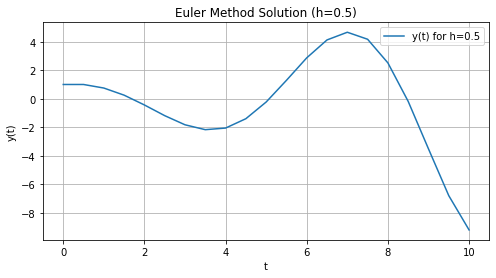

In [4]:
k = 1.0   # default spring constant
step_sizes = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

for h in step_sizes:
    A = euler_matrix(k, h)
    eigenvals = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvals)

    print(f"\nStep size h = {h}")
    print(f"Eigenvalues: {eigenvals}")
    print(f"Magnitudes: {magnitudes}")

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    # simulate and plot
    t, y, v = simulate_euler(k, h)

    plt.figure(figsize=(8,4))
    plt.plot(t, y, label=f"y(t) for h={h}")
    plt.title(f"Euler Method Solution (h={h})")
    plt.xlabel("t")
    plt.ylabel("y(t)")
    plt.grid(True)
    plt.legend()
    plt.show()

## Case: k = 10, h = 0.01


Case: k = 10, h = 0.01
Eigenvalues: [1.+0.03162278j 1.-0.03162278j]
Magnitudes: [1.00049988 1.00049988]
Solution may not be Entirely Stable ;)


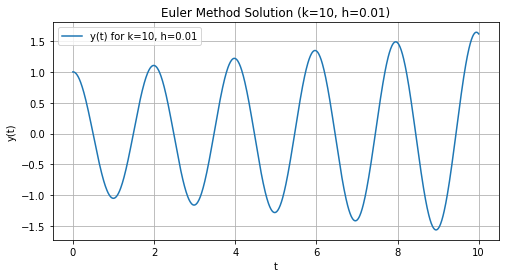

In [5]:
k = 10
h = 0.01

A = euler_matrix(k, h)
eigenvals = np.linalg.eigvals(A)
magnitudes = np.abs(eigenvals)

print(f"\nCase: k = {k}, h = {h}")
print(f"Eigenvalues: {eigenvals}")
print(f"Magnitudes: {magnitudes}")

if np.all(magnitudes < 1):
    print("Solution is Stable")
else:
    print("Solution may not be Entirely Stable ;)")

t, y, v = simulate_euler(k, h)

plt.figure(figsize=(8,4))
plt.plot(t, y, label=f"y(t) for k={k}, h={h}")
plt.title(f"Euler Method Solution (k={k}, h={h})")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()